# Analyse exploratoire des données - Campagne marketing

## 0. Objectif
Ce notebook a pour objectif de :
- comprendre la structure des données de campagne
- vérifier leur qualité
- identifier les facteurs liés à la réponse au mailing
- préparer les transformations nécessaires pour le scoring et le reporting

## 1. Import des librairies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Chargement des données

In [4]:
df = pd.read_csv(r"..\data\raw\mailing_fin.txt",sep=None, engine="python")
df.head(5)

,RETOUR,AGE,INCOME,SEX,MARRIED,FICO,OWNHOME,LOC,BUY6,BUY12,BUY18,VALUE24,COA6,fin
0,NON,45,52,F,1,748,0,A,0,0,0,209,0,0
1,NON,56,79,NaN,1,732,0,A,0,0,0,109,0,0
2,OUI,49,54,F,0,727,0,A,0,0,1,447,0,0
3,OUI,44,40,NaN,1,708,1,A,0,0,0,151,0,0
4,NON,59,41,F,0,646,1,A,0,0,0,233,0,0


## 3. Compréhension général du dataset

In [5]:
print("Dimensions du dataset : ")
df.shape

Dimensions du dataset : 


(39779, 14)

Nous disposons de 14 variables et de 39779 observations. Il s'agit des répondants au mail de campagne envoyé.

In [6]:
print("Types de données : ")
df.info()

Types de données : 
<class 'pandas.DataFrame'>
RangeIndex: 39779 entries, 0 to 39778
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   RETOUR   39779 non-null  str  
 1   AGE      39779 non-null  int64
 2   INCOME   39779 non-null  int64
 3   SEX      39721 non-null  str  
 4   MARRIED  39779 non-null  int64
 5   FICO     39779 non-null  int64
 6   OWNHOME  39779 non-null  int64
 7   LOC      39779 non-null  str  
 8   BUY6     39779 non-null  int64
 9   BUY12    39779 non-null  int64
 10  BUY18    39779 non-null  int64
 11  VALUE24  39779 non-null  int64
 12  COA6     39779 non-null  int64
 13  fin      39779 non-null  int64
dtypes: int64(11), str(3)
memory usage: 4.2 MB


Les variables sont deux type : les chaines de caractère et les entiers. Des modifications vont être opérés au niveau de certaines variables pour plus de facilité dans l'analyse et dans le calcul du score plus loin dans l'étude. Les variables qualitatives seront recodés pour facilité la comprehension des modalités.

### 3.1. Changement de type de données pour les variables catégorielles

In [7]:
df[["RETOUR","SEX","COA6","LOC","MARRIED","OWNHOME","fin"]]=df[["RETOUR","SEX","COA6","LOC","MARRIED","OWNHOME","fin"]].astype("category")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39779 entries, 0 to 39778
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   RETOUR   39779 non-null  category
 1   AGE      39779 non-null  int64   
 2   INCOME   39779 non-null  int64   
 3   SEX      39721 non-null  category
 4   MARRIED  39779 non-null  category
 5   FICO     39779 non-null  int64   
 6   OWNHOME  39779 non-null  category
 7   LOC      39779 non-null  category
 8   BUY6     39779 non-null  int64   
 9   BUY12    39779 non-null  int64   
 10  BUY18    39779 non-null  int64   
 11  VALUE24  39779 non-null  int64   
 12  COA6     39779 non-null  category
 13  fin      39779 non-null  category
dtypes: category(7), int64(7)
memory usage: 2.4 MB


### 3.2. Statistiques descriptives

In [8]:
print ("Statistiques descriptives des varaibles quantitatives : ")
df[["AGE","INCOME","FICO","VALUE24", "BUY6", "BUY12","BUY18"]].describe().round(2).T

Statistiques descriptives des varaibles quantitatives : 


,count,mean,std,min,25%,50%,75%,max
AGE,39779.0,44.30,10.22,18.0,38.0,44.0,50.0,75.0
INCOME,39779.0,47.78,16.04,15.0,35.0,50.0,61.0,128.0
FICO,39779.0,693.70,28.82,565.0,675.0,695.0,713.0,810.0
VALUE24,39779.0,254.21,154.43,60.0,149.0,215.0,311.0,1317.0
BUY6,39779.0,0.13,0.35,0.0,0.0,0.0,0.0,2.0
BUY12,39779.0,0.22,0.45,0.0,0.0,0.0,0.0,3.0
BUY18,39779.0,0.36,0.59,0.0,0.0,0.0,1.0,4.0


In [9]:
print ("Statistiques descriptives des varaibles qualitatives : ")
df[["RETOUR","SEX","COA6","LOC","MARRIED","OWNHOME","fin"]].describe(include="category").T

Statistiques descriptives des varaibles qualitatives : 


,count,unique,top,freq
RETOUR,39779,2,NON,34376
SEX,39721,2,M,21205
COA6,39779,2,0,38627
LOC,39779,8,E,8918
MARRIED,39779,2,1,22918
OWNHOME,39779,2,0,26704
fin,39779,1,0,39779


La variable "fin" n'a qu'une seule modalité. Elle ne sera pas utile dans l'analyse, elle sera supprimée.

## 4. Analyse de la qualité des données

### 4.1. Valeurs manquantes et doublons

In [10]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("missing_count", ascending=False)
missing

,missing_count,missing_%
SEX,58,0.15
RETOUR,0,0.00
AGE,0,0.00
INCOME,0,0.00
MARRIED,0,0.00
FICO,0,0.00
OWNHOME,0,0.00
LOC,0,0.00
BUY6,0,0.00
BUY12,0,0.00


La seule variable qui comprend des valeurs manquantes est la variable "SEX". Les valeurs manquantes seront remplacées par "Inconnu".

In [11]:
df.duplicated().sum()

np.int64(0)

Notre série de données ne comporte pas de doublons.

### 4.2. Imputation des valeurs manquantes
Remplacement des valeurs manquantes dans la variable "SEX" par 0 M=1 et F=2
Type=object

In [12]:
df['SEX'] = df['SEX'].cat.add_categories(['Inconnu']).fillna('Inconnu')

In [13]:
# Vérification des valeurs manquantes après le recodage
df.isna().sum()

RETOUR     0
AGE        0
INCOME     0
SEX        0
MARRIED    0
FICO       0
OWNHOME    0
LOC        0
BUY6       0
BUY12      0
BUY18      0
VALUE24    0
COA6       0
fin        0
dtype: int64

La variable "fin" ayant une seule modalité, ne contient aucune information utile. Elle va être supprimée.

In [14]:
df.drop('fin',axis='columns', inplace=True)
df.head(3)

,RETOUR,AGE,INCOME,SEX,MARRIED,FICO,OWNHOME,LOC,BUY6,BUY12,BUY18,VALUE24,COA6
0,NON,45,52,F,1,748,0,A,0,0,0,209,0
1,NON,56,79,Inconnu,1,732,0,A,0,0,0,109,0
2,OUI,49,54,F,0,727,0,A,0,0,1,447,0


### 4.3. Recodage des variables quantitatives
rendre numerique celles qu il faut
regrouper en classe

### 4.4. Recodage des variables qualitatives
Transformer les lettres en chiffres (mais type object)

### 4.5. Création de la variable RFM (Recence Frequence Montant)

L'objectif dans cette section est de segmenter les clients par catégorie suivant leur comportement. On se base sur la recence (depuis combien de temps le client a acheté), la frequence (combien de fois il a acheté) et le montant (combien il a dépensé).

In [15]:
# Recodage de la variable RETOUR
df.insert(
    df.columns.get_loc('RETOUR') + 1,
    'RETOUR_rec', None) #création de la nouvelle colonne juste après RETOUR

df['RETOUR_rec'] = df['RETOUR'].map({'NON': 0, 'OUI': 1}).astype(int)

In [16]:
df.head(5)

,RETOUR,RETOUR_rec,AGE,INCOME,SEX,MARRIED,FICO,OWNHOME,LOC,BUY6,BUY12,BUY18,VALUE24,COA6
0,NON,0,45,52,F,1,748,0,A,0,0,0,209,0
1,NON,0,56,79,Inconnu,1,732,0,A,0,0,0,109,0
2,OUI,1,49,54,F,0,727,0,A,0,0,1,447,0
3,OUI,1,44,40,Inconnu,1,708,1,A,0,0,0,151,0
4,NON,0,59,41,F,0,646,1,A,0,0,0,233,0


## 5. Analyse univariée
Analyse de chaque variable seule

Faisons une nouvelle analyse descriptive après nettoyage des données.

In [17]:
print ("Nouvelles statistiques descriptives des variables quantitatives : ")
df[["AGE","INCOME","FICO","VALUE24", "BUY6", "BUY12","BUY18"]].describe().round(2).T

Nouvelles statistiques descriptives des variables quantitatives : 


,count,mean,std,min,25%,50%,75%,max
AGE,39779.0,44.30,10.22,18.0,38.0,44.0,50.0,75.0
INCOME,39779.0,47.78,16.04,15.0,35.0,50.0,61.0,128.0
FICO,39779.0,693.70,28.82,565.0,675.0,695.0,713.0,810.0
VALUE24,39779.0,254.21,154.43,60.0,149.0,215.0,311.0,1317.0
BUY6,39779.0,0.13,0.35,0.0,0.0,0.0,0.0,2.0
BUY12,39779.0,0.22,0.45,0.0,0.0,0.0,0.0,3.0
BUY18,39779.0,0.36,0.59,0.0,0.0,0.0,1.0,4.0


Commentaire : 

In [18]:
print ("Nouvelles statistiques descriptives des variables qualitatives : ")
df[["SEX","COA6","LOC","MARRIED","OWNHOME"]].describe(include="category").T

Nouvelles statistiques descriptives des variables qualitatives : 


,count,unique,top,freq
SEX,39779,3,M,21205
COA6,39779,2,0,38627
LOC,39779,8,E,8918
MARRIED,39779,2,1,22918
OWNHOME,39779,2,0,26704


Ce tableau représente les statistiques descriptives des variables qualitatives. La colonne "count" compte le nombre d'observations pour chaque variable, la colonne "unique" compte le nombre de modalités uniques pour chaque variable, la colonne "top" renseigne sur la modalité la plus observée pour chaque variable : dans notre base de données, les répondants sont majoritairement des hommes, des personnes qui n'ont pas demenagées, localisés dans la zone E, mariés, qui ne sont pas propriétaires. La colonne "freq" donne l'effectif pour la modalité dominante.

La variable cible "RETOUR" a cette repartition : 34376 clients ont répondu à la campagne contre 5403 non répondants. Ceci représente respectivement 86,42% et 13,58%.

In [19]:
retour_counts = df['RETOUR_rec'].value_counts()
retour_pourcentages = df['RETOUR_rec'].value_counts(normalize=True) * 100

# Créer un tableau récapitulatif
retour_recap = pd.DataFrame({
    'Effectif': retour_counts,
    'Pourcentage': retour_pourcentages.round(2)}
)

print("==== Analyse de Fréquence de la variable cible (RETOUR_rec) ====")
print(retour_recap)

==== Analyse de Fréquence de la variable cible (RETOUR_rec) ====
            Effectif  Pourcentage
RETOUR_rec                       
0              34376        86.42
1               5403        13.58


## 6. Analyse bivariée

### 6.1. Analyse du profil des répondants et non répondants

In [20]:
# Séparation des variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('RETOUR_rec')
cat_cols = df.select_dtypes(include=['category']).columns.drop('RETOUR')

#Analyse du profil avec les variables numériques
table_num = df.groupby('RETOUR_rec')[num_cols].mean().T.round(2)
table_num.columns = ['Non répondants', 'Répondants']

table_num

,Non répondants,Répondants
AGE,44.73,41.60
INCOME,47.77,47.85
FICO,694.26,690.11
BUY6,0.13,0.15
BUY12,0.21,0.26
BUY18,0.34,0.51
VALUE24,249.78,282.41


In [21]:
#Analyse du profil avec les variables catégorielles
summary_cat = []

for col in cat_cols:
    table = (pd.crosstab(df[col], df['RETOUR_rec'], normalize='columns') * 100).round(2)

    for modalite in table.index:
        summary_cat.append([
            col,
            modalite,
            table.loc[modalite, 0] if 0 in table.columns else 0,
            table.loc[modalite, 1] if 1 in table.columns else 0
        ])

summary_cat_df = pd.DataFrame(summary_cat, 
                              columns=['Variable', 'Modalité', 'Non répondants (%)', 'Répondants (%)'])

summary_cat_df

,Variable,Modalité,Non répondants (%),Répondants (%)
0,SEX,F,46.23,48.57
1,SEX,M,53.62,51.30
2,SEX,Inconnu,0.15,0.13
3,MARRIED,0,43.02,38.39
4,MARRIED,1,56.98,61.61
5,OWNHOME,0,65.77,75.77
6,OWNHOME,1,34.23,24.23
7,LOC,A,6.30,7.37
8,LOC,B,18.32,18.93
9,LOC,C,5.40,8.87


### 6.3. Analyse du lien entre variables explicatives et la variable à expliquer et de la corrélation

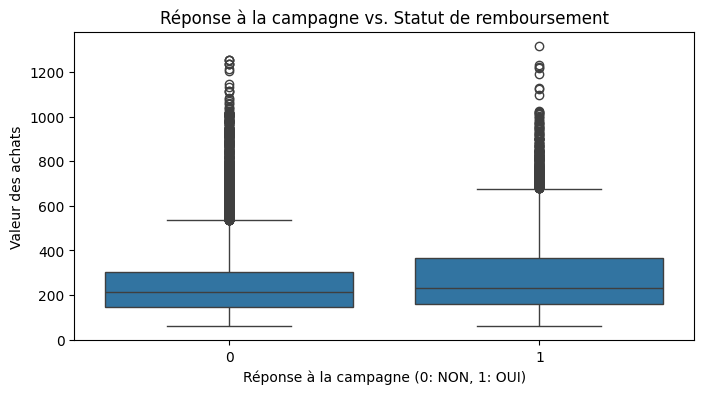

n==== Test T de Student pour loan_amnt ====
Statistique T : -inf
P-value : 0.00000


c:\Users\marln\Documents\Projets\Data Marketing\marketing-campaign-scoring-analysis\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [26]:
from scipy.stats import ttest_ind

# Analyse graphique : Boxplots
plt.figure(figsize=(8,4))
sns.boxplot(x='RETOUR_rec', y='VALUE24', data=df)
plt.title('Réponse à la campagne vs. Statut de remboursement')
plt.xlabel('Réponse à la campagne (0: NON, 1: OUI)')
plt.ylabel('Valeur des achats')
plt.show()

# Test Statistique : Test T de Student
# Filtrer les montants par statut
rep = df[df['RETOUR_rec'] == 0]['RETOUR_rec'].dropna()
defaut = df[df['RETOUR_rec'] == 1]['RETOUR_rec'].dropna()

# Le Test T de Student permet de voir si les moyennes des deux groupes sont statistiquement différentes
statistic, p_value = ttest_ind(rep, defaut, equal_var=False)

print(f"n==== Test T de Student pour loan_amnt ====")
print(f"Statistique T : {statistic:.2f}")
print(f"P-value : {p_value:.5f}")

## 7. La modélisation
Gestion des valeurs aberrantes
Mise en reference des variables catégorielle
Pondération des classes
Modelisation
Creation du score et choix du seuil optimal

## 8. Conclusion